# GFv2 Parameter Results — Visual QA

Spatial maps of merged parameter outputs in `gfv2/params/merged/`, joined to the HRU fabric.

| File | Parameters | Type |
|---|---|---|
| `nhm_elevation_params.csv` | `mean` elevation | continuous (m) |
| `nhm_slope_params.csv` | `mean` slope | continuous (°) |
| `nhm_aspect_params.csv` | `mean` aspect | circular (0–360°) |
| `nhm_soils_params.csv` | `soils` | categorical (1=sand, 2=loam, 3=clay) |
| `nhm_soil_moist_max_params.csv` | `soil_moist_max` | continuous (cm) |
| `nhm_lulc_nhm_v11_params.csv` | `cov_type`, `covden_sum`, `covden_win`, `retention`, `srain_intcp`, `wrain_intcp`, `snow_intcp` | mixed |

HRU fabric: `gfv2/fabric/gfv2_nhru_merged.gpkg` (361,471 HRUs, EPSG:5070).
All joins are on `nat_hru_id`.

In [15]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

DATA_ROOT  = Path("/caldera/hovenweep/projects/usgs/water/impd/nhgf/gfv2_param_v2")
FABRIC     = DATA_ROOT / "gfv2" / "fabric" / "gfv2_nhru_merged.gpkg"
PARAMS_DIR = DATA_ROOT / "gfv2" / "params" / "merged"


## Load fabric and verify available parameters

In [16]:
fabric = gpd.read_file(FABRIC)
print(f"Fabric: {len(fabric):,} HRUs  CRS: {fabric.crs}")

for p in sorted(PARAMS_DIR.glob("nhm_*.csv")):
    df = pd.read_csv(p, nrows=0)
    ok = p.stat().st_size > 1000
    print(f"  {'OK' if ok else 'MISSING'}  {p.name:45s}  columns: {df.columns.tolist()}")


Fabric: 361,471 HRUs  CRS: EPSG:5070
  OK  nhm_aspect_params.csv                          columns: ['nat_hru_id', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'sum']
  OK  nhm_elevation_params.csv                       columns: ['nat_hru_id', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'sum']
  OK  nhm_lulc_nhm_v11_params.csv                    columns: ['nat_hru_id', 'cov_type', 'srain_intcp', 'wrain_intcp', 'snow_intcp', 'covden_sum', 'covden_win', 'retention']
  OK  nhm_slope_params.csv                           columns: ['nat_hru_id', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'sum']
  OK  nhm_soil_moist_max_params.csv                  columns: ['nat_hru_id', 'soil_moist_max']
  OK  nhm_soils_params.csv                           columns: ['nat_hru_id', 'soils']


## Helper functions

In [17]:
def load_params(filename: str, col: str = None) -> gpd.GeoDataFrame:
    """Load a param CSV, join to the fabric on nat_hru_id, return a GeoDataFrame."""
    df = pd.read_csv(PARAMS_DIR / filename)
    gdf = fabric[["nat_hru_id", "geometry"]].merge(df, on="nat_hru_id", how="left")
    if col and col not in gdf.columns:
        raise KeyError(f"Column '{col}' not in {filename}. Available: {df.columns.tolist()}")
    return gdf


def map_continuous(gdf, col, title, units="", cmap="viridis",
                   pct_lo=2, pct_hi=98, figsize=(14, 7)):
    """Choropleth map + histogram for a continuous parameter column."""
    vals = gdf[col].dropna()
    vmin, vmax = np.percentile(vals, [pct_lo, pct_hi])

    fig, (ax_map, ax_hist) = plt.subplots(
        1, 2, figsize=figsize, gridspec_kw={"width_ratios": [3, 1]}
    )
    gdf.plot(column=col, cmap=cmap, vmin=vmin, vmax=vmax,
             linewidth=0, ax=ax_map, legend=True,
             legend_kwds={"label": units, "shrink": 0.6, "pad": 0.01},
             missing_kwds={"color": "lightgrey", "label": "No data"})
    ax_map.set_title(title, fontsize=11)
    ax_map.axis("off")

    ax_hist.hist(vals, bins=100, color="steelblue", edgecolor="none", density=True)
    p25, p50, p75 = np.percentile(vals, [25, 50, 75])
    ax_hist.axvline(p25,  color="cornflowerblue", ls="--", lw=1.2, label=f"p25 = {p25:.3g}")
    ax_hist.axvline(p50,  color="navy",           ls="-",  lw=1.8, label=f"p50 = {p50:.3g}")
    ax_hist.axvline(p75,  color="cornflowerblue", ls="--", lw=1.2, label=f"p75 = {p75:.3g}")
    ax_hist.axvline(vmin, color="orange",         ls=":",  lw=1.2, label=f"stretch lo = {vmin:.3g}")
    ax_hist.axvline(vmax, color="red",            ls=":",  lw=1.2, label=f"stretch hi = {vmax:.3g}")
    ax_hist.set_title(
        f"n = {len(vals):,}  mean = {vals.mean():.4g}\nstd = {vals.std():.4g}",
        fontsize=8, loc="left", family="monospace",
    )
    ax_hist.set_xlabel(units or col)
    ax_hist.set_ylabel("density")
    ax_hist.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def map_categorical(gdf, col, title, labels=None, colors=None, figsize=(14, 7)):
    """Choropleth map for a categorical parameter column."""
    cats = sorted(gdf[col].dropna().unique())
    if colors is None:
        colors = list(plt.cm.Set2.colors[:len(cats)])
    cmap = mcolors.ListedColormap(colors[:len(cats)])
    norm = mcolors.BoundaryNorm([c - 0.5 for c in cats] + [cats[-1] + 0.5], len(cats))

    fig, (ax_map, ax_leg) = plt.subplots(
        1, 2, figsize=figsize, gridspec_kw={"width_ratios": [4, 1]}
    )
    gdf.plot(column=col, cmap=cmap, norm=norm,
             linewidth=0, ax=ax_map,
             missing_kwds={"color": "lightgrey"})
    ax_map.set_title(title, fontsize=11)
    ax_map.axis("off")

    counts = gdf[col].value_counts().sort_index()
    total  = counts.sum()
    patches = []
    for cat, color in zip(cats, colors[:len(cats)]):
        lbl = labels.get(cat, str(cat)) if labels else str(cat)
        n   = counts.get(cat, 0)
        patches.append(Patch(color=color, label=f"{lbl}\n({n:,}, {100*n/total:.1f}%)"))
    ax_leg.legend(handles=patches, loc="center", frameon=False, fontsize=9)
    ax_leg.axis("off")
    plt.tight_layout()
    plt.show()


## Elevation (`nhm_elevation_params.csv`)

Mean elevation of each HRU derived from NHDPlus DEM, zonal-averaged at 30 m.

- **Parameter:** `mean` (m above sea level)
- **Expected range:** 0–4,300 m; low in coastal plains and river valleys, high in Rocky Mountains and Sierra Nevada
- **Role in model:** Drives temperature lapse-rate corrections; used in snow/rain partitioning and PET adjustments in PRMS/NHM

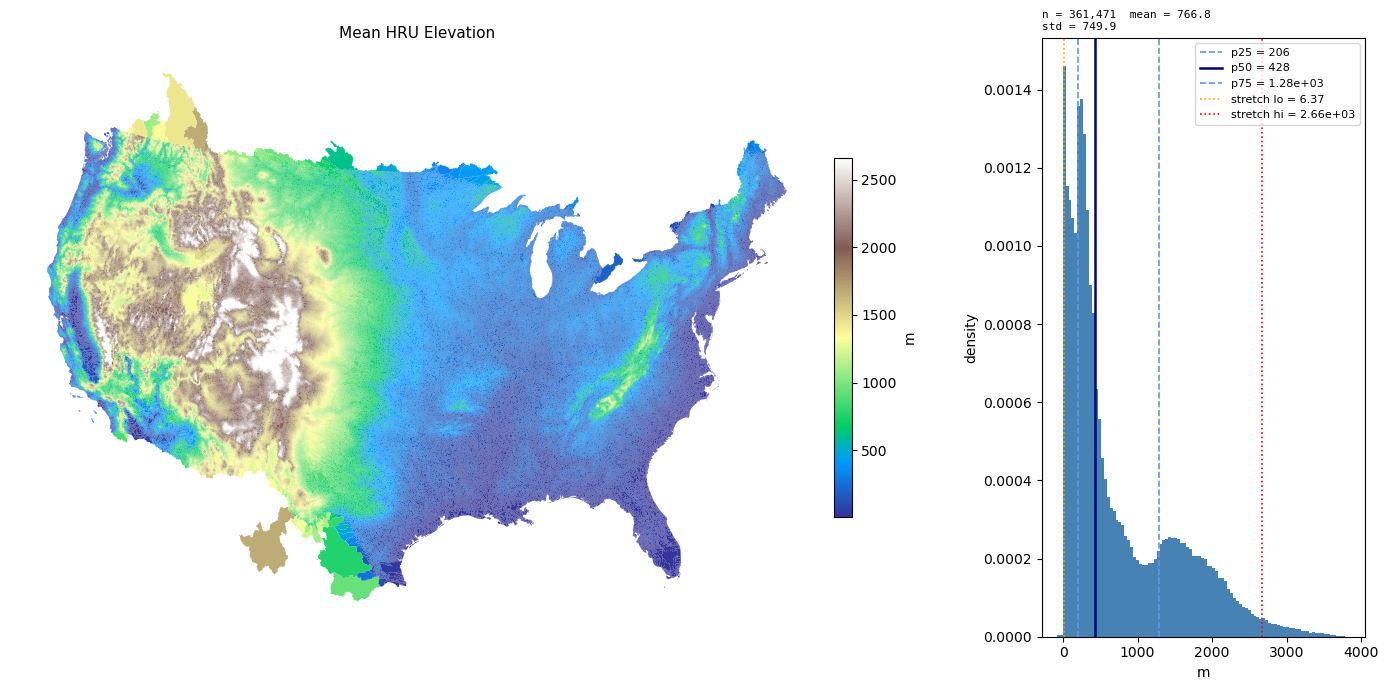

In [21]:
gdf_elev = load_params("nhm_elevation_params.csv", "mean")
map_continuous(gdf_elev, "mean", "Mean HRU Elevation", units="m", cmap="terrain")


## Slope (`nhm_slope_params.csv`)

Mean slope angle of each HRU derived from the NHDPlus DEM.

- **Parameter:** `mean` (degrees)
- **Expected range:** 0–90°; near 0° in flat plains and valley floors, 20–40°+ in mountain terrain
- **Role in model:** Influences overland-flow routing speed and subsurface lateral flow; steeper HRUs drain faster under the PRMS kinematic wave routing

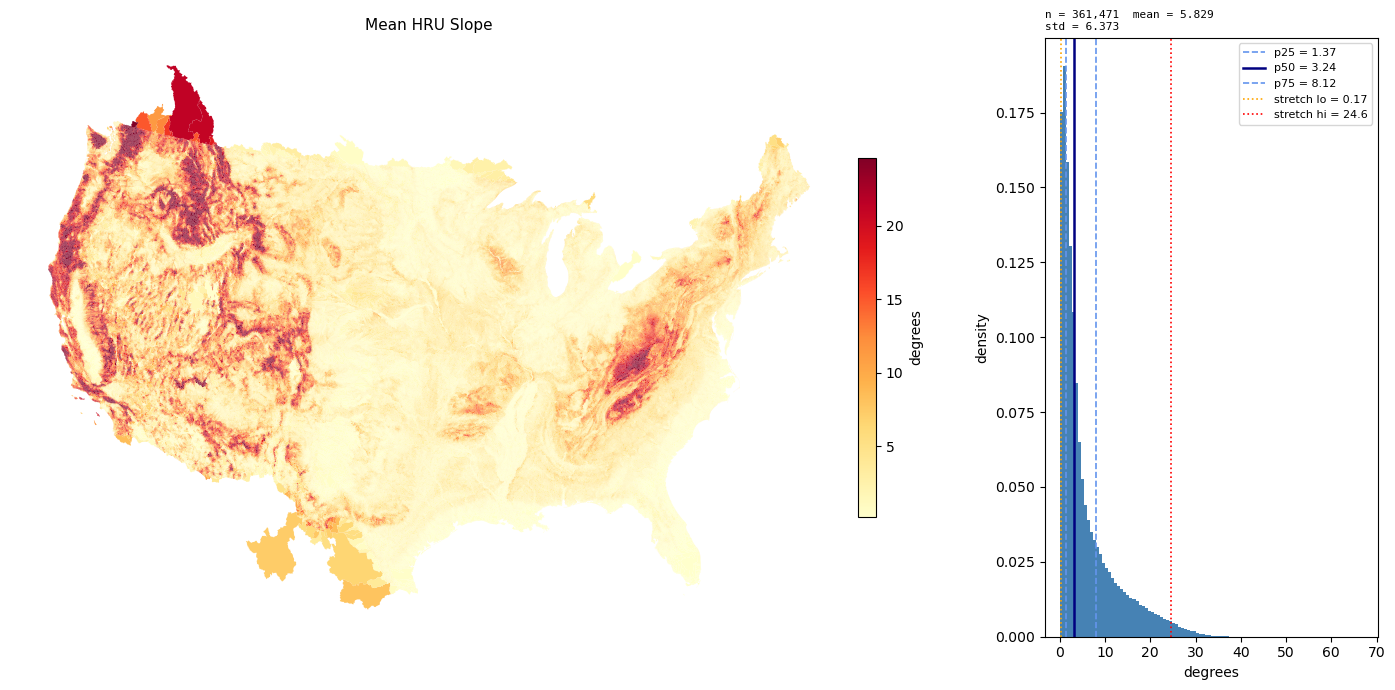

In [22]:
gdf_slope = load_params("nhm_slope_params.csv", "mean")
map_continuous(gdf_slope, "mean", "Mean HRU Slope", units="degrees", cmap="YlOrRd")


## Aspect (`nhm_aspect_params.csv`)

Mean solar aspect of each HRU — the compass direction the terrain faces.

- **Parameter:** `mean` (degrees; 0 = north, 90 = east, 180 = south, 270 = west)
- **Note:** Aspect is a circular variable; the arithmetic mean is a simplification. North- and south-facing slopes (0°/360° vs 180°) are climatically opposite despite being near-neighbours numerically.
- **Role in model:** Controls direct-beam solar radiation incident on each HRU; south-facing slopes receive more insolation, melt snow faster, and have higher PET.  Used to compute `swrad_adj` in PRMS

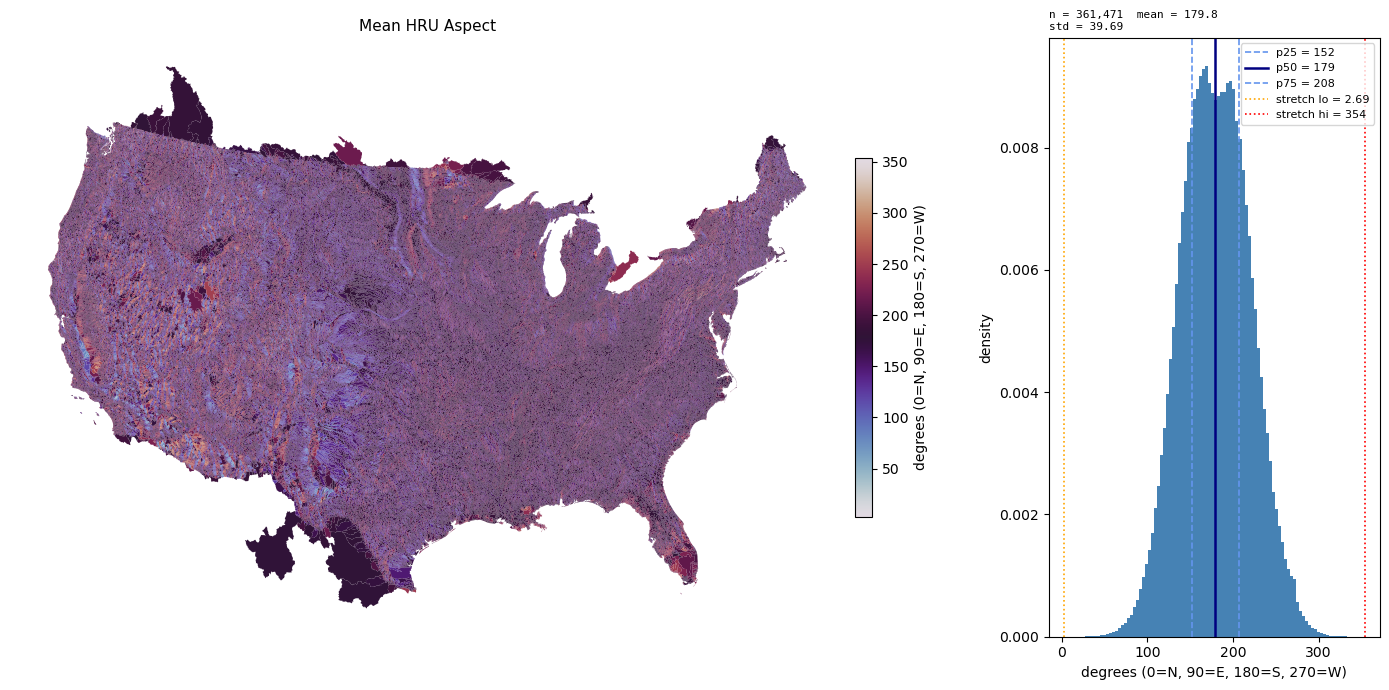

In [20]:
gdf_aspect = load_params("nhm_aspect_params.csv", "mean")
map_continuous(gdf_aspect, "mean",
               "Mean HRU Aspect",
               units="degrees (0=N, 90=E, 180=S, 270=W)",
               cmap="twilight", pct_lo=0, pct_hi=100)


## Soil Texture Class (`nhm_soils_params.csv`)

Modal soil texture class for each HRU, derived from STATSGO/SSURGO.

- **1 = Sand / coarse** — rapid drainage, low water-holding capacity (~31% of HRUs)
- **2 = Loam / medium** — moderate drainage, moderate water-holding capacity (~69% of HRUs, dominant)
- **3 = Clay / fine** — slow drainage, high water-holding capacity (~0.4% of HRUs)
- **Role in model:** Selects soil hydraulic parameter sets in the PRMS soil zone; used as an index for `soil2gw_max` and `ssr2gw_rate` lookups

In [ ]:
gdf_soils = load_params("nhm_soils_params.csv", "soils")
map_categorical(
    gdf_soils, "soils",
    "Soil Texture Class",
    labels={1: "1 – Sand/coarse", 2: "2 – Loam/medium", 3: "3 – Clay/fine"},
    colors=["#f0c04a", "#8b6340", "#4d7c4f"],
)


## Soil Moisture Max (`nhm_soil_moist_max_params.csv`)

Maximum plant-available soil-water storage in the root zone: root depth (cm) × AWC (cm/cm).

- **Parameter:** `soil_moist_max` (cm)
- **Expected range:** ~2–80 cm; low in rocky/sandy soils, high in deep loamy forest soils
- **Grey/zero HRUs:** Cropland-dominated HRUs have `RootDepth = 0` in the source product (no natural root-depth estimate); a gap-fill step assigning a default crop root depth (~30–50 cm) is needed before model runs
- **Role in model:** Primary soil-zone capacity parameter in PRMS/NHM; larger values slow baseflow recession and buffer peak flows

In [ ]:
gdf_smmax = load_params("nhm_soil_moist_max_params.csv", "soil_moist_max")
map_continuous(gdf_smmax, "soil_moist_max",
               "Soil Moisture Max (root depth x AWC)",
               units="cm", cmap="Blues")


## LULC: Cover Type (`nhm_lulc_nhm_v11_params.csv`)

Dominant vegetation/cover type class for each HRU, derived from NHM v1.1 LULC raster.

- **0 = Bare/impervious** — rock, urban, open water
- **1 = Grass/shrub** — grasslands, shrublands, low vegetation
- **2 = Shrub/mixed** — mixed shrub and open woodland
- **3 = Trees** — closed-canopy forest (dominant class, ~53% of HRUs)
- **Role in model:** Controls interception capacity tables and canopy density in the PRMS `intcp` module

In [ ]:
gdf_lulc = load_params("nhm_lulc_nhm_v11_params.csv")
map_categorical(
    gdf_lulc, "cov_type",
    "Cover Type (cov_type)",
    labels={0: "0 – Bare/impervious", 1: "1 – Grass/shrub",
            2: "2 – Shrub/mixed",    3: "3 – Trees"},
    colors=["#c0c0c0", "#d4e09b", "#a0c878", "#2d6a2d"],
)


## LULC: Canopy Density — Summer and Winter

Mean fractional canopy cover for each HRU in summer and winter seasons.

- **`covden_sum`** (0–1): Summer canopy density; highest in deciduous + evergreen forests
- **`covden_win`** (0–1): Winter canopy density; evergreen-only signal after deciduous leaves drop; highlights conifer-dominated regions
- **Role in model:** Scales the effective canopy area that intercepts precipitation and reduces sub-canopy shortwave radiation

In [ ]:
map_continuous(gdf_lulc, "covden_sum", "Summer Canopy Density (covden_sum)",
               units="fraction (0-1)", cmap="Greens")
map_continuous(gdf_lulc, "covden_win", "Winter Canopy Density (covden_win)",
               units="fraction (0-1)", cmap="YlGn")


## LULC: Canopy Retention and Interception Depths

- **`retention`** (0–1): Annual-average canopy water retention; combines summer canopy density and winter retention factor
- **`snow_intcp`** (in, 0–0.10): Snow interception storage depth — highest for dense conifers
- **`srain_intcp`** (in, 0–0.05): Summer rainfall interception storage depth
- **`wrain_intcp`** (in, 0–0.05): Winter rainfall interception storage depth
- **Role in model:** Scale canopy interception loss per storm event in the PRMS `intcp` module; larger values reduce throughfall reaching the soil zone

In [ ]:
map_continuous(gdf_lulc, "retention",   "Canopy Retention",              units="fraction (0-1)", cmap="PuBuGn")
map_continuous(gdf_lulc, "snow_intcp",  "Snow Interception Depth",        units="in",             cmap="PuBu")
map_continuous(gdf_lulc, "srain_intcp", "Summer Rain Interception Depth", units="in",             cmap="BuPu")
map_continuous(gdf_lulc, "wrain_intcp", "Winter Rain Interception Depth", units="in",             cmap="BuPu")


## Side-by-side overview: all continuous parameters

In [ ]:
panels = [
    (gdf_elev,  "mean",           "Elevation (m)",       "terrain"),
    (gdf_slope, "mean",           "Slope (deg)",         "YlOrRd"),
    (gdf_smmax, "soil_moist_max", "Soil Moist Max (cm)", "Blues"),
    (gdf_lulc,  "covden_sum",     "Covden Summer",       "Greens"),
    (gdf_lulc,  "covden_win",     "Covden Winter",       "YlGn"),
    (gdf_lulc,  "retention",      "Retention",           "PuBuGn"),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, (gdf, col, label, cmap) in zip(axes.flat, panels):
    vals = gdf[col].dropna()
    vmin, vmax = np.percentile(vals, [2, 98])
    gdf.plot(column=col, cmap=cmap, vmin=vmin, vmax=vmax,
             linewidth=0, ax=ax, legend=True,
             legend_kwds={"shrink": 0.5, "pad": 0.01},
             missing_kwds={"color": "lightgrey"})
    ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.suptitle("GFv2 HRU parameters — p2-p98 stretch", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
